# **T.Kanishka CS24b2046**

### *Watershed alogrithm*

Foreground markers: 15
Total number of circles/dots: 15


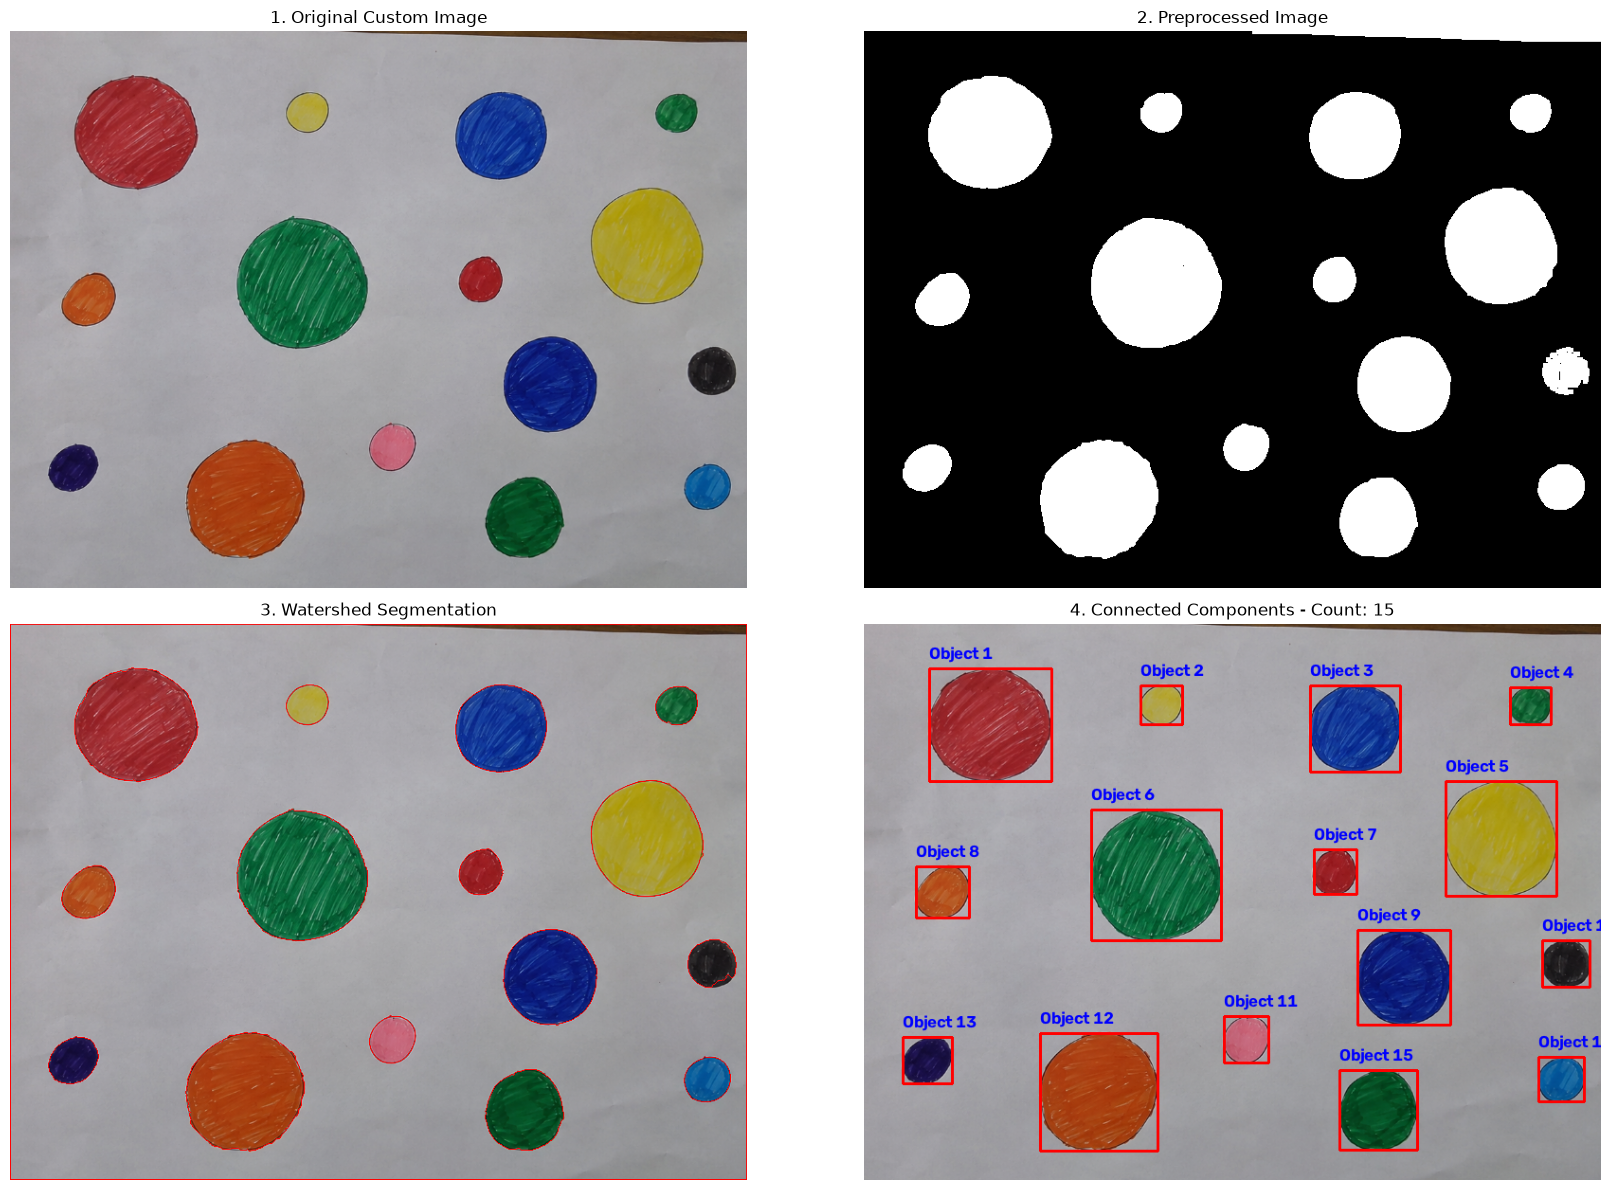

--------------------------------------
FINAL RESULT
--------------------------------------
Total circles/dots detected: 15


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read input image
image = cv2.imread("image.png")

if image is None:
    raise FileNotFoundError("image.png not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. To GrayScale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blur = cv2.GaussianBlur(gray,(5, 5),0)

# 3. Create binary image
# Since the objects are colored and the background
# is mostly white, HSV saturation is used to detect
# colored circles.
#
# The black circle has low saturation, so it is
# additionally detected using grayscale intensity.

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

saturation = hsv[:, :, 1]

# Colored objects
color_objects = saturation > 50

# Black/dark object
dark_objects = gray < 60

# Combine both
binary = np.zeros_like(gray)

binary[color_objects | dark_objects] = 255

# 4. Morphological opening
# Removes small noise from the captured image.

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel,iterations=2)


# 5. Sure background
# Dilation expands the foreground regions and gives
# us the sure-background region.
sure_bg = cv2.dilate(opening,kernel,iterations=3)

# 6. Distance transform
# Distance transform gives the distance of each
# foreground pixel from the nearest background pixel.
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)

# 7. Sure foreground
# The center of each circle has a high distance value.
# 0.2 is used so that even the small circles obtain
# a foreground marker.
_, sure_fg = cv2.threshold(
    dist_transform,
    0.2 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# 8. Unknown region
unknown = cv2.subtract(sure_bg,sure_fg)

# 9. Create markers for Watershed
# Each connected foreground region gets a unique
# marker/label.

num_markers, markers = cv2.connectedComponents(sure_fg)
print("Foreground markers:", num_markers - 1)

# Background is assigned marker 1
markers = markers + 1

# Unknown region is assigned marker 0
markers[unknown == 255] = 0

# 10. Apply Watershed Algorithm
watershed_markers = cv2.watershed(image.copy(),markers)

# 11. Watershed visualization
watershed_result = image_rgb.copy()

# Watershed boundaries are marked in red
watershed_result[watershed_markers == -1] = [255, 0, 0]

# 12. Create segmented image
# Pixels belonging to watershed objects have
# marker values greater than 1.

segmented = np.zeros_like(gray)
segmented[watershed_markers > 1] = 255

# 13. Connected Component Analysis

num_labels, labels, stats, centroids = \
    cv2.connectedComponentsWithStats(
        segmented,
        connectivity=8
    )

total_objects = num_labels - 1

print("Total number of circles/dots:", total_objects)

# 14. Label every detected object

labeled_image = image_rgb.copy()

for i in range(1, num_labels):

    # Bounding box
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]

    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]

    # Centroid
    cx, cy = centroids[i]

    # Draw bounding rectangle
    cv2.rectangle(
        labeled_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    # Draw object number
    cv2.putText(
        labeled_image,
        f"Object {i}",
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

# 15. Display required outputs

plt.figure(figsize=(18, 12))


# Original image
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("1. Original Custom Image")
plt.axis("off")

# Preprocessed image
plt.subplot(2, 2, 2)
plt.imshow(opening, cmap="gray")
plt.title("2. Preprocessed Image")
plt.axis("off")

# Watershed segmentation
plt.subplot(2, 2, 3)
plt.imshow(watershed_result)
plt.title("3. Watershed Segmentation")
plt.axis("off")

# Connected components
plt.subplot(2, 2, 4)
plt.imshow(labeled_image)
plt.title(
    f"4. Connected Components - Count: {total_objects}"
)
plt.axis("off")
plt.tight_layout()
plt.show()


print("--------------------------------------")
print("FINAL RESULT")
print("--------------------------------------")

print(
    "Total circles/dots detected:",
    total_objects
)

Foreground markers: 33
Total number of circles/dots: 8


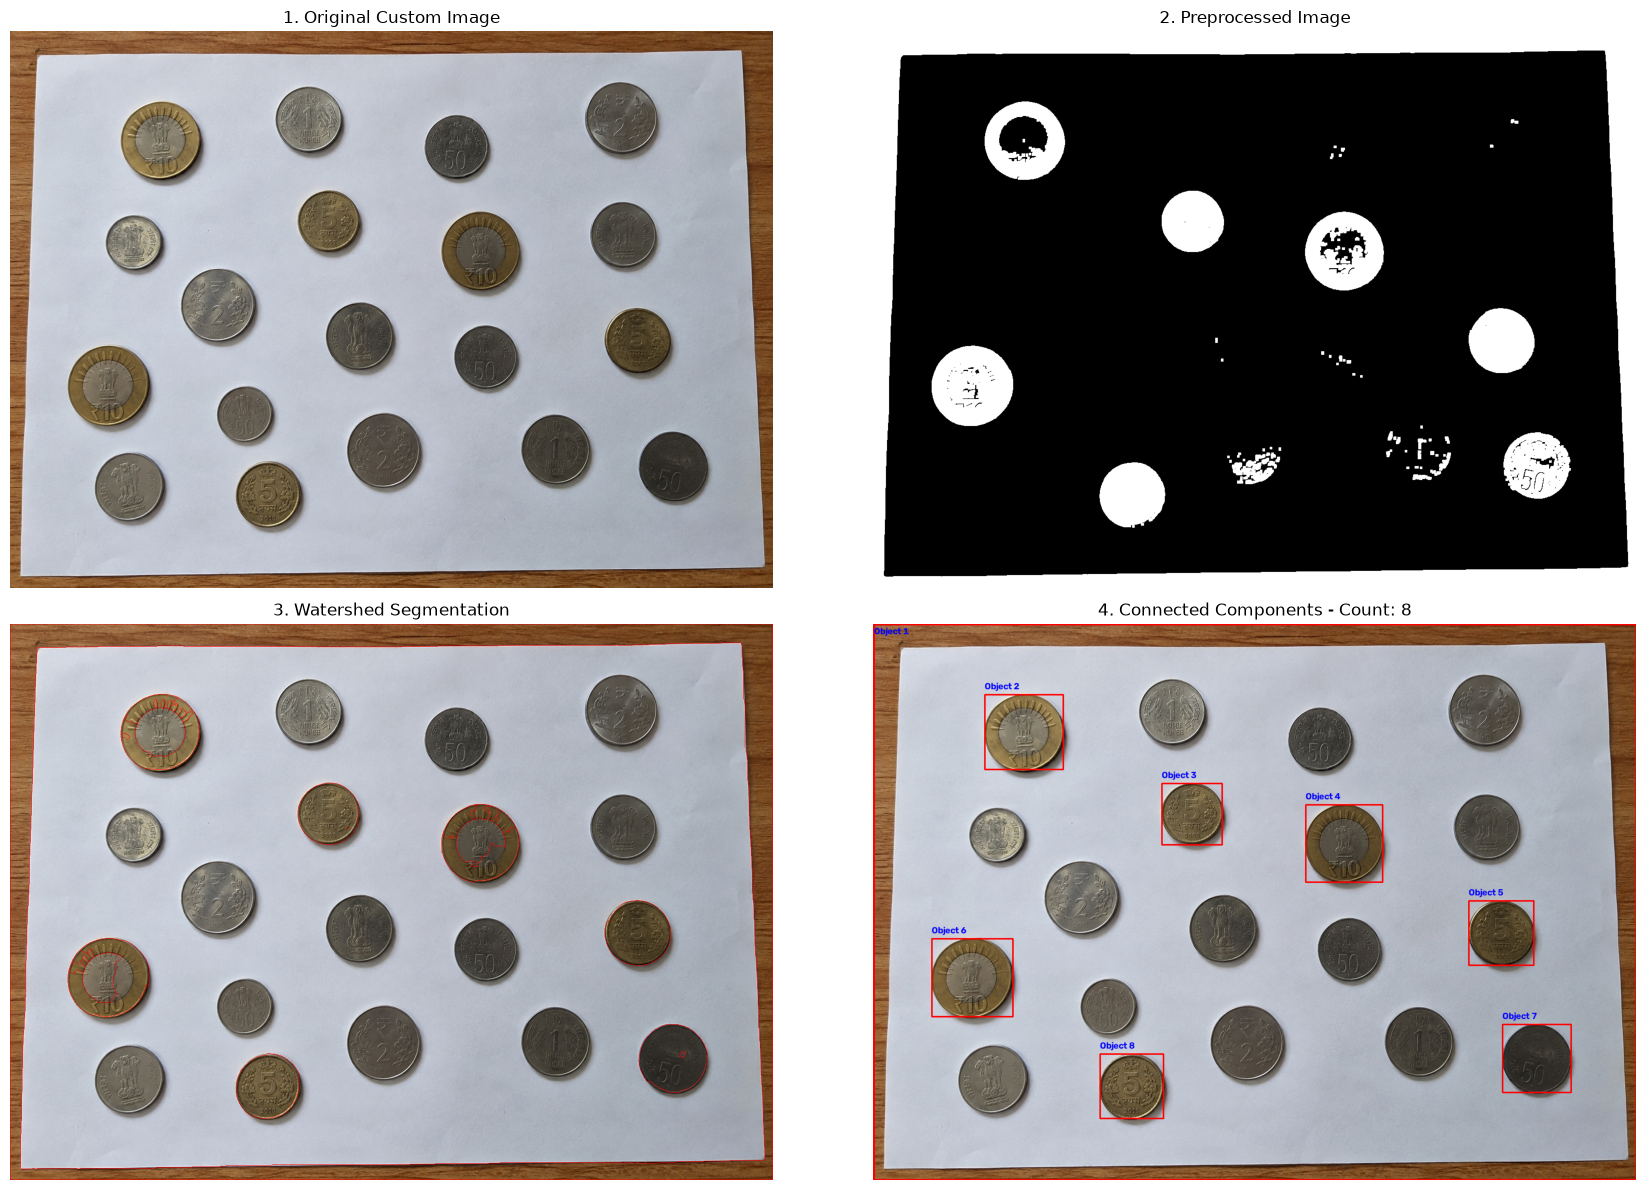

--------------------------------------
FINAL RESULT
--------------------------------------
Total circles/dots detected: 8


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read input image
image = cv2.imread("coins.png")

if image is None:
    raise FileNotFoundError("image.png not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. To GrayScale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blur = cv2.GaussianBlur(gray,(5, 5),0)

# 3. Create binary image
# Since the objects are colored and the background
# is mostly white, HSV saturation is used to detect
# colored circles.
#
# The black circle has low saturation, so it is
# additionally detected using grayscale intensity.

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

saturation = hsv[:, :, 1]

# Colored objects
color_objects = saturation > 50

# Black/dark object
dark_objects = gray < 60

# Combine both
binary = np.zeros_like(gray)

binary[color_objects | dark_objects] = 255

# 4. Morphological opening
# Removes small noise from the captured image.

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel,iterations=2)


# 5. Sure background
# Dilation expands the foreground regions and gives
# us the sure-background region.
sure_bg = cv2.dilate(opening,kernel,iterations=3)

# 6. Distance transform
# Distance transform gives the distance of each
# foreground pixel from the nearest background pixel.
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)

# 7. Sure foreground
# The center of each circle has a high distance value.
# 0.2 is used so that even the small circles obtain
# a foreground marker.
_, sure_fg = cv2.threshold(
    dist_transform,
    0.2 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# 8. Unknown region
unknown = cv2.subtract(sure_bg,sure_fg)

# 9. Create markers for Watershed
# Each connected foreground region gets a unique
# marker/label.

num_markers, markers = cv2.connectedComponents(sure_fg)
print("Foreground markers:", num_markers - 1)

# Background is assigned marker 1
markers = markers + 1

# Unknown region is assigned marker 0
markers[unknown == 255] = 0

# 10. Apply Watershed Algorithm
watershed_markers = cv2.watershed(image.copy(),markers)

# 11. Watershed visualization
watershed_result = image_rgb.copy()

# Watershed boundaries are marked in red
watershed_result[watershed_markers == -1] = [255, 0, 0]

# 12. Create segmented image
# Pixels belonging to watershed objects have
# marker values greater than 1.

segmented = np.zeros_like(gray)
segmented[watershed_markers > 1] = 255

# 13. Connected Component Analysis

num_labels, labels, stats, centroids = \
    cv2.connectedComponentsWithStats(
        segmented,
        connectivity=8
    )

total_objects = num_labels - 1

print("Total number of circles/dots:", total_objects)

# 14. Label every detected object

labeled_image = image_rgb.copy()

for i in range(1, num_labels):

    # Bounding box
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]

    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]

    # Centroid
    cx, cy = centroids[i]

    # Draw bounding rectangle
    cv2.rectangle(
        labeled_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    # Draw object number
    cv2.putText(
        labeled_image,
        f"Object {i}",
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

# 15. Display required outputs

plt.figure(figsize=(18, 12))


# Original image
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("1. Original Custom Image")
plt.axis("off")

# Preprocessed image
plt.subplot(2, 2, 2)
plt.imshow(opening, cmap="gray")
plt.title("2. Preprocessed Image")
plt.axis("off")

# Watershed segmentation
plt.subplot(2, 2, 3)
plt.imshow(watershed_result)
plt.title("3. Watershed Segmentation")
plt.axis("off")

# Connected components
plt.subplot(2, 2, 4)
plt.imshow(labeled_image)
plt.title(
    f"4. Connected Components - Count: {total_objects}"
)
plt.axis("off")
plt.tight_layout()
plt.show()


print("--------------------------------------")
print("FINAL RESULT")
print("--------------------------------------")

print(
    "Total circles/dots detected:",
    total_objects
)

Foreground markers: 24
Total number of circles/dots: 1


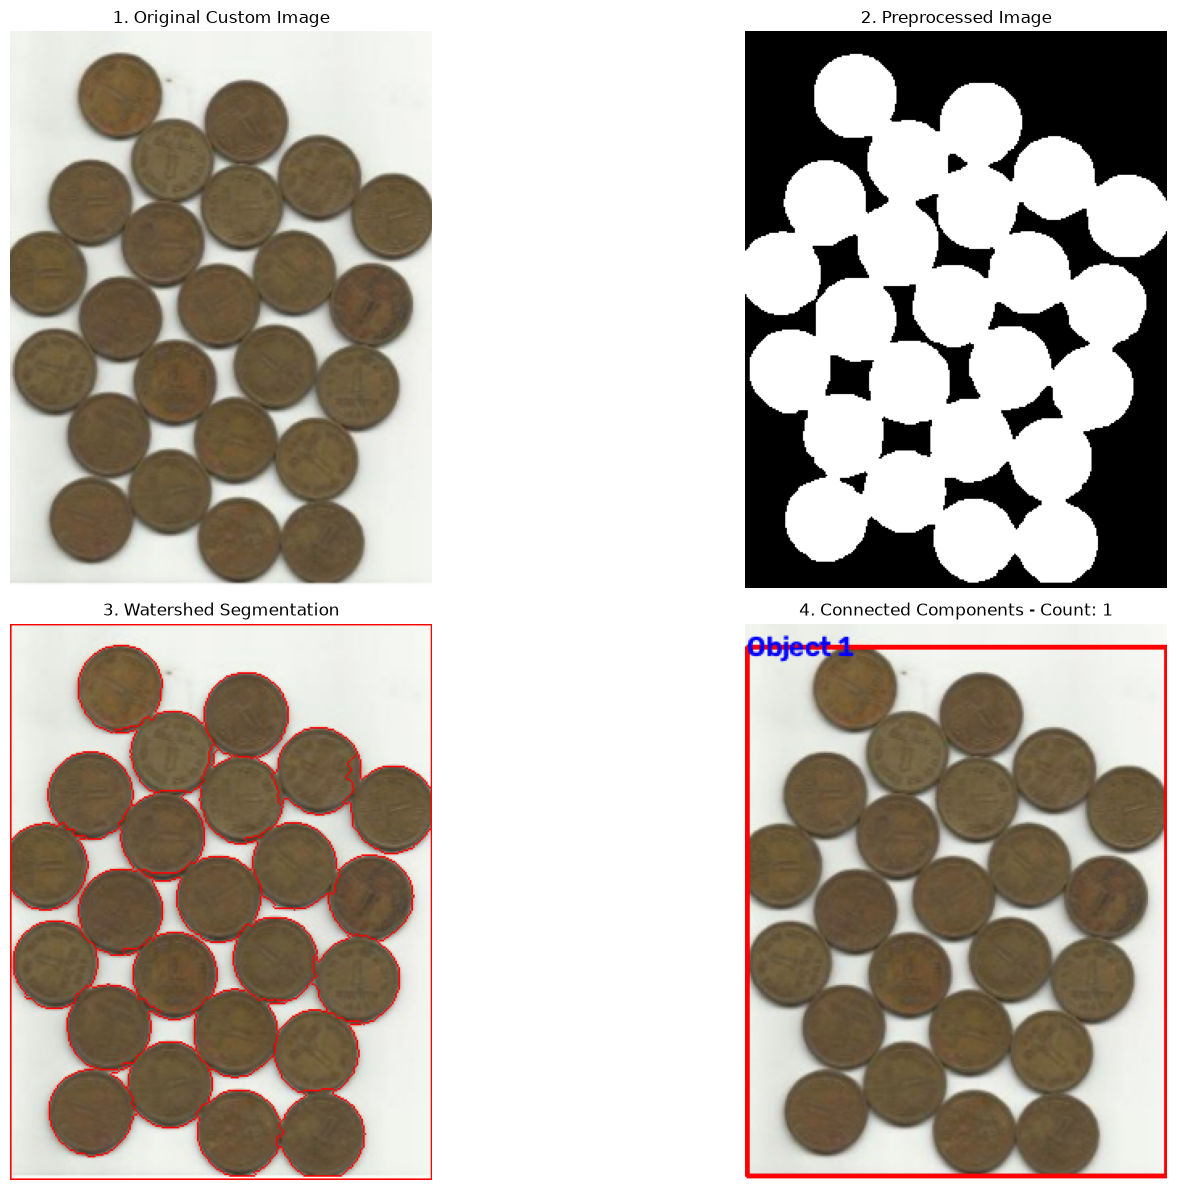

--------------------------------------
FINAL RESULT
--------------------------------------
Total circles/dots detected: 1


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read input image
image = cv2.imread("coinsoverlap.png")

if image is None:
    raise FileNotFoundError("image.png not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. To GrayScale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blur = cv2.GaussianBlur(gray,(5, 5),0)

# 3. Create binary image
# Since the objects are colored and the background
# is mostly white, HSV saturation is used to detect
# colored circles.
#
# The black circle has low saturation, so it is
# additionally detected using grayscale intensity.

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

saturation = hsv[:, :, 1]

# Colored objects
color_objects = saturation > 50

# Black/dark object
dark_objects = gray < 60

# Combine both
binary = np.zeros_like(gray)

binary[color_objects | dark_objects] = 255

# 4. Morphological opening
# Removes small noise from the captured image.

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel,iterations=2)


# 5. Sure background
# Dilation expands the foreground regions and gives
# us the sure-background region.
sure_bg = cv2.dilate(opening,kernel,iterations=3)

# 6. Distance transform
# Distance transform gives the distance of each
# foreground pixel from the nearest background pixel.
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)

# 7. Sure foreground
# The center of each circle has a high distance value.
# 0.2 is used so that even the small circles obtain
# a foreground marker.
_, sure_fg = cv2.threshold(
    dist_transform,
    0.4 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# 8. Unknown region
unknown = cv2.subtract(sure_bg,sure_fg)

# 9. Create markers for Watershed
# Each connected foreground region gets a unique
# marker/label.

num_markers, markers = cv2.connectedComponents(sure_fg)
print("Foreground markers:", num_markers - 1)

# Background is assigned marker 1
markers = markers + 1

# Unknown region is assigned marker 0
markers[unknown == 255] = 0

# 10. Apply Watershed Algorithm
watershed_markers = cv2.watershed(image.copy(),markers)

# 11. Watershed visualization
watershed_result = image_rgb.copy()

# Watershed boundaries are marked in red
watershed_result[watershed_markers == -1] = [255, 0, 0]

# 12. Create segmented image
# Pixels belonging to watershed objects have
# marker values greater than 1.

segmented = np.zeros_like(gray)
segmented[watershed_markers > 1] = 255

# 13. Connected Component Analysis

num_labels, labels, stats, centroids = \
    cv2.connectedComponentsWithStats(
        segmented,
        connectivity=8
    )

total_objects = num_labels - 1

print("Total number of circles/dots:", total_objects)

# 14. Label every detected object

labeled_image = image_rgb.copy()

for i in range(1, num_labels):

    # Bounding box
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]

    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]

    # Centroid
    cx, cy = centroids[i]

    # Draw bounding rectangle
    cv2.rectangle(
        labeled_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    # Draw object number
    cv2.putText(
        labeled_image,
        f"Object {i}",
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

# 15. Display required outputs

plt.figure(figsize=(18, 12))


# Original image
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("1. Original Custom Image")
plt.axis("off")

# Preprocessed image
plt.subplot(2, 2, 2)
plt.imshow(opening, cmap="gray")
plt.title("2. Preprocessed Image")
plt.axis("off")

# Watershed segmentation
plt.subplot(2, 2, 3)
plt.imshow(watershed_result)
plt.title("3. Watershed Segmentation")
plt.axis("off")

# Connected components
plt.subplot(2, 2, 4)
plt.imshow(labeled_image)
plt.title(
    f"4. Connected Components - Count: {total_objects}"
)
plt.axis("off")
plt.tight_layout()
plt.show()


print("--------------------------------------")
print("FINAL RESULT")
print("--------------------------------------")

print(
    "Total circles/dots detected:",
    total_objects
)

Foreground markers: 23
--------------------------------
FINAL RESULT
--------------------------------
Total coins detected: 16


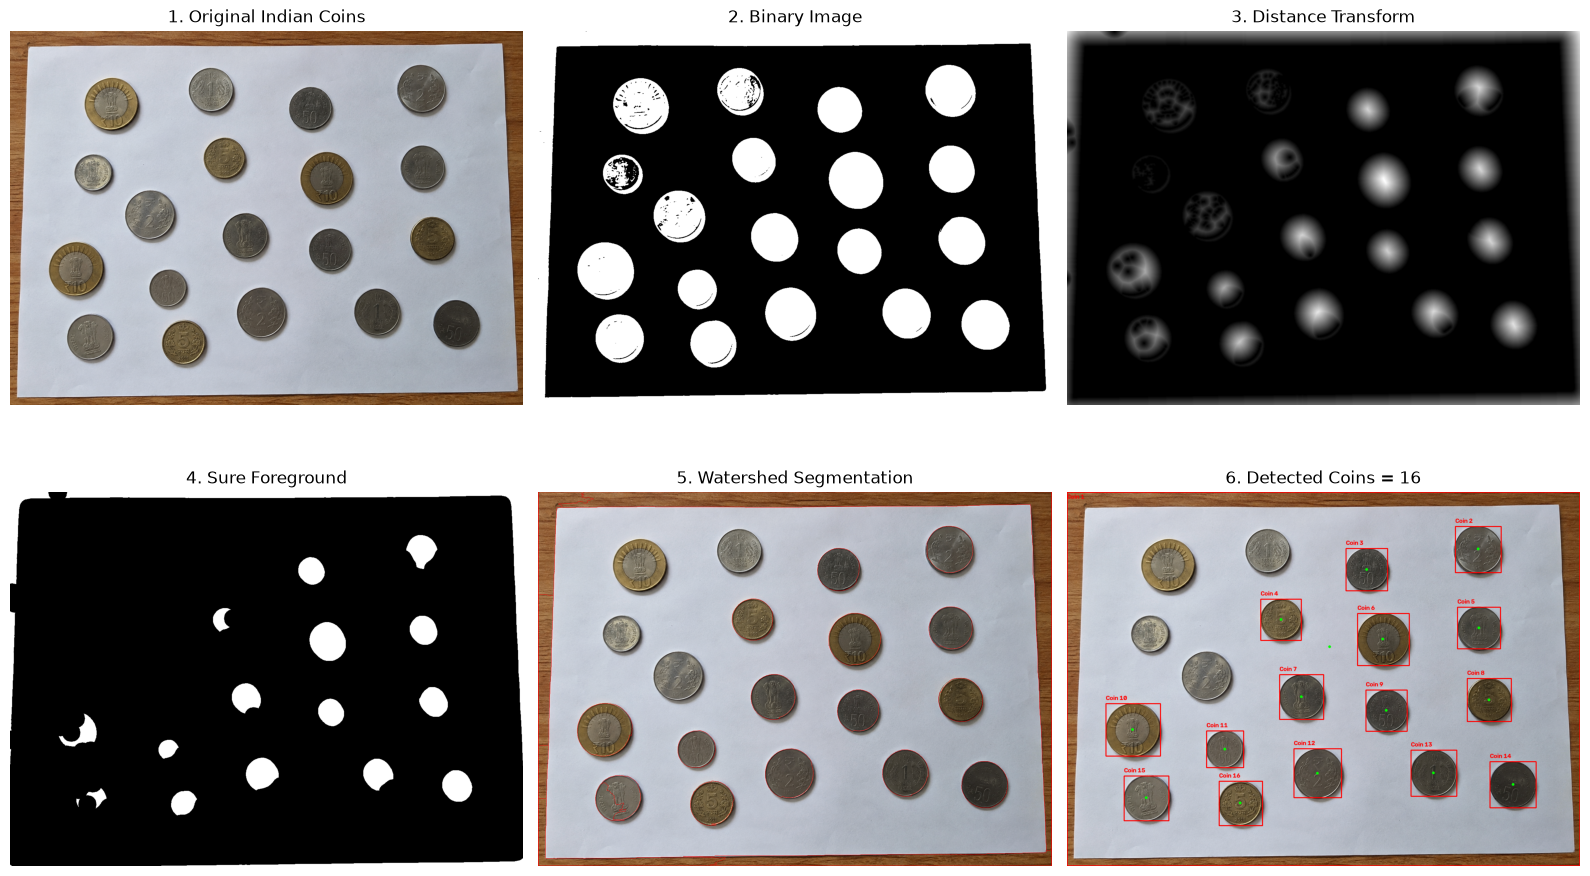

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image
image = cv2.imread("coins.png")

if image is None:
    raise FileNotFoundError("indian_coins.jpg not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Blur the image to reduce noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Create binary image
# Coins are separated from the background using Otsu thresholding
_, binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# If the background is detected as white instead of black,
# invert the binary image
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

# 5. Morphological opening
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# 6. Sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

# 7. Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# 8. Sure foreground
# Coin centers have high distance values
_, sure_fg = cv2.threshold(
    dist_transform,
    0.35 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# 9. Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# 10. Create markers
num_markers, markers = cv2.connectedComponents(
    sure_fg
)

print("Foreground markers:", num_markers - 1)

# Background becomes 1
markers = markers + 1

# Unknown region becomes 0
markers[unknown == 255] = 0

# 11. Apply Watershed
watershed_markers = cv2.watershed(
    image.copy(),
    markers
)

# 12. Show Watershed boundaries
watershed_result = image_rgb.copy()

watershed_result[
    watershed_markers == -1
] = [255, 0, 0]

# 13. Create segmented image
segmented = np.zeros_like(gray)

segmented[
    watershed_markers > 1
] = 255

# 14. Connected Component Analysis
num_labels, labels, stats, centroids = \
    cv2.connectedComponentsWithStats(
        segmented,
        connectivity=8
    )

total_coins = num_labels - 1

print("--------------------------------")
print("FINAL RESULT")
print("--------------------------------")
print("Total coins detected:", total_coins)

# 15. Draw bounding boxes and labels
labeled_image = image_rgb.copy()

for i in range(1, num_labels):

    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]

    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]

    cx, cy = centroids[i]

    # Bounding box
    cv2.rectangle(
        labeled_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    # Centroid
    cv2.circle(
        labeled_image,
        (int(cx), int(cy)),
        4,
        (0, 255, 0),
        -1
    )

    # Object number
    cv2.putText(
        labeled_image,
        f"Coin {i}",
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

# 16. Display results
plt.figure(figsize=(16, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("1. Original Indian Coins")
plt.axis("off")

# Binary
plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("2. Binary Image")
plt.axis("off")

# Distance transform
plt.subplot(2, 3, 3)
plt.imshow(dist_transform, cmap="gray")
plt.title("3. Distance Transform")
plt.axis("off")

# Sure foreground
plt.subplot(2, 3, 4)
plt.imshow(sure_fg, cmap="gray")
plt.title("4. Sure Foreground")
plt.axis("off")

# Watershed
plt.subplot(2, 3, 5)
plt.imshow(watershed_result)
plt.title("5. Watershed Segmentation")
plt.axis("off")

# Final
plt.subplot(2, 3, 6)
plt.imshow(labeled_image)
plt.title(f"6. Detected Coins = {total_coins}")
plt.axis("off")

plt.tight_layout()
plt.show()

Foreground markers: 10
--------------------------------
FINAL RESULT
--------------------------------
Total coins detected: 10


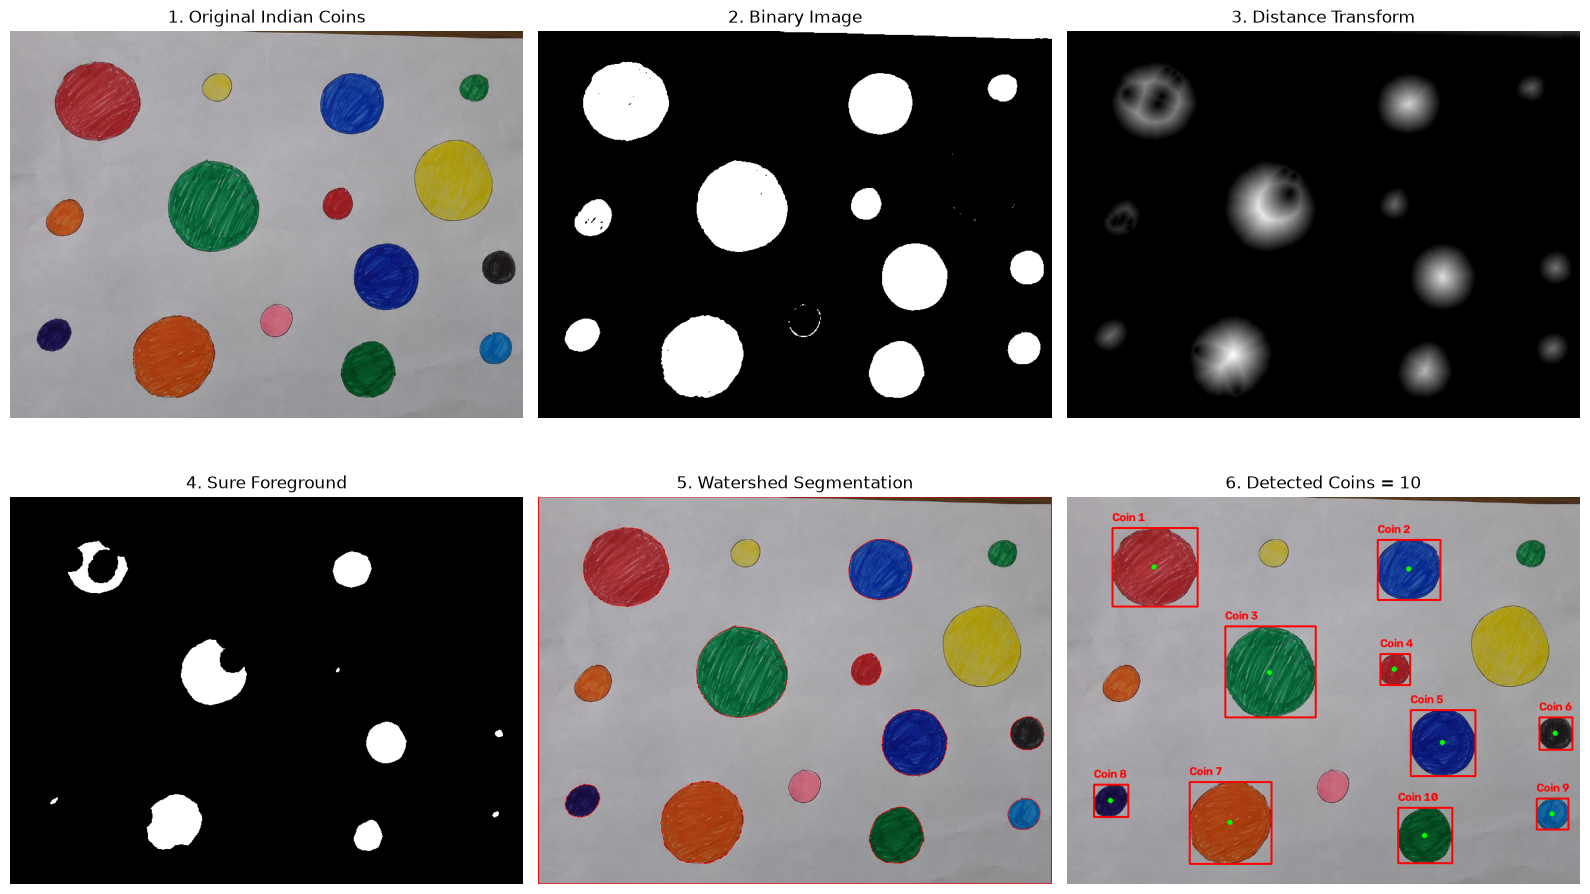

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image
image = cv2.imread("image.png")

if image is None:
    raise FileNotFoundError("indian_coins.jpg not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Blur the image to reduce noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Create binary image
# Coins are separated from the background using Otsu thresholding
_, binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# If the background is detected as white instead of black,
# invert the binary image
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

# 5. Morphological opening
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# 6. Sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

# 7. Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# 8. Sure foreground
# Coin centers have high distance values
_, sure_fg = cv2.threshold(
    dist_transform,
    0.35 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# 9. Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# 10. Create markers
num_markers, markers = cv2.connectedComponents(
    sure_fg
)

print("Foreground markers:", num_markers - 1)

# Background becomes 1
markers = markers + 1

# Unknown region becomes 0
markers[unknown == 255] = 0

# 11. Apply Watershed
watershed_markers = cv2.watershed(
    image.copy(),
    markers
)

# 12. Show Watershed boundaries
watershed_result = image_rgb.copy()

watershed_result[
    watershed_markers == -1
] = [255, 0, 0]

# 13. Create segmented image
segmented = np.zeros_like(gray)

segmented[
    watershed_markers > 1
] = 255

# 14. Connected Component Analysis
num_labels, labels, stats, centroids = \
    cv2.connectedComponentsWithStats(
        segmented,
        connectivity=8
    )

total_coins = num_labels - 1

print("--------------------------------")
print("FINAL RESULT")
print("--------------------------------")
print("Total coins detected:", total_coins)

# 15. Draw bounding boxes and labels
labeled_image = image_rgb.copy()

for i in range(1, num_labels):

    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]

    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]

    cx, cy = centroids[i]

    # Bounding box
    cv2.rectangle(
        labeled_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    # Centroid
    cv2.circle(
        labeled_image,
        (int(cx), int(cy)),
        4,
        (0, 255, 0),
        -1
    )

    # Object number
    cv2.putText(
        labeled_image,
        f"Coin {i}",
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

# 16. Display results
plt.figure(figsize=(16, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("1. Original Indian Coins")
plt.axis("off")

# Binary
plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("2. Binary Image")
plt.axis("off")

# Distance transform
plt.subplot(2, 3, 3)
plt.imshow(dist_transform, cmap="gray")
plt.title("3. Distance Transform")
plt.axis("off")

# Sure foreground
plt.subplot(2, 3, 4)
plt.imshow(sure_fg, cmap="gray")
plt.title("4. Sure Foreground")
plt.axis("off")

# Watershed
plt.subplot(2, 3, 5)
plt.imshow(watershed_result)
plt.title("5. Watershed Segmentation")
plt.axis("off")

# Final
plt.subplot(2, 3, 6)
plt.imshow(labeled_image)
plt.title(f"6. Detected Coins = {total_coins}")
plt.axis("off")

plt.tight_layout()
plt.show()